# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

Primero importaré las librerías necesarias para trabajar con los archivo .csv, como pandas.

Después usaré la función <code>read_csv("nombre", sep=";")</code> para poder crear dataframes de cada archivo.

Finalmente, usaré métodos asociados al dataframe para poder describir los datos, por ejemplo:
* info(): para el resumen general.
* head(): para una primera visualización del DF.
* describe(): para enlistar las características estadísticas de los valores numéricos.
* duplicated(): para ver si existen duplicados.

In [2]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [3]:
# leer conjuntos de datos en los DataFrames
df_orders = pd.read_csv('datasets/instacart_orders.csv', sep = ";")
df_products = pd.read_csv('datasets/products.csv', sep = ";")
df_aisles = pd.read_csv('datasets/aisles.csv', sep = ";")
df_departments = pd.read_csv('datasets/departments.csv', sep = ";")
df_order_products = pd.read_csv('datasets/order_products.csv', sep = ";")

In [4]:
# mostrar información del DataFrame df_orders
print("Información del DataFrame df_orders:")
print(df_orders.info())
print("================================")
print("\nPrimeras filas del DataFrame df_orders:")
print(df_orders.head())
print("================================")
print("\nDescripción estadística del DataFrame df_orders:")
print(df_orders.describe())
print("================================")
print("\nValores duplicados en el DataFrame df_orders:")
print(df_orders.duplicated().sum())

Información del DataFrame df_orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None

Primeras filas del DataFrame df_orders:
   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0       

In [5]:
# mostrar información del DataFrame
print("Información del DataFrame df_products:")
print(df_products.info())
print("================================")
print("\nPrimeras filas del DataFrame df_products:")
print(df_products.head())
print("================================")
print("\nValores duplicados en el DataFrame df_products:")
print(df_products.duplicated().sum())

print("\nLa columna 'product_name' tiene los siguiente tipos de datos", 
      "\n", df_products['product_name'].apply(type).value_counts())

Información del DataFrame df_products:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None

Primeras filas del DataFrame df_products:
   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0        

Aquí se puede visualizar como los valores nulos de la columna product name estan catalogados como float.

In [6]:
# mostrar información del DataFrame
print("Información del DataFrame df_order_products:")
print(df_order_products.info(show_counts=True))
print("================================")
print("\nPrimeras filas del DataFrame df_order_products:")
print(df_order_products.head())
print("================================")
print("\nValores duplicados en el DataFrame df_order_products:")
print(df_order_products.duplicated().sum())

Información del DataFrame df_order_products:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None

Primeras filas del DataFrame df_order_products:
   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1

Valores duplicados en el DataFrame df_order_products:
0


In [7]:
# mostrar información del DataFrame
print("Información del DataFrame df_aisles:")
print(df_aisles.info())
print("================================")
print("\nPrimeras filas del DataFrame df_aisles:")
print(df_aisles.head())
print("================================")
print("\nValores duplicados en el DataFrame df_aisles:")
print(df_aisles.duplicated().sum())

print("\nLa columna 'aisle' tiene los siguiente tipos de datos", "\n", df_aisles['aisle'].apply(type).value_counts())

Información del DataFrame df_aisles:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None

Primeras filas del DataFrame df_aisles:
   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation

Valores duplicados en el DataFrame df_aisles:
0

La columna 'aisle' tiene los siguiente tipos de datos 
 aisle
<class 'str'>    134
Name: count, dtype: int64


In [8]:
# mostrar información del DataFrame
print("Información del DataFrame df_departments:")
print(df_departments.info())
print("================================")
print("\nPrimeras filas del DataFrame df_departments:")
print(df_departments.head())
print("================================")
print("\nValores duplicados en el DataFrame df_departments:")
print(df_departments.duplicated().sum())

print("\nLa columna 'department' tiene los siguiente tipos de datos", "\n", df_departments['department'].apply(type).value_counts())

Información del DataFrame df_departments:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes
None

Primeras filas del DataFrame df_departments:
   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol

Valores duplicados en el DataFrame df_departments:
0

La columna 'department' tiene los siguiente tipos de datos 
 department
<class 'str'>    21
Name: count, dtype: int64


## Conclusiones

Tenemos valores ausentes en algunas columnas de los archivos "instacart_orders.csv", df_orders; "products.csv", df_products; "order_products.csv", df_order_products. 

También, en la columna "product_name" en df_products tiene valores tipo float cuando esperábamos solamente strings. 

Por último podemos notar valores duplicados en df_orders.

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Analizaremos cada archivo que necesite atención. 
1.  **df_orders**
    1.  Analizar la lista de duplicados para saber si es necesario eliminarlos o hacer alguna anotación de que se pidió el producto varias veces.
    2.  Revisar valores nulos en la columna 'days_since_prior_order'.

2.  **df_products**
    1.  Analizar la columna 'product_name' y el porque tiene datos tipo float para tratarlos modificándolos o eliminándolos.

3. **df_order_products**
   1. Analizar los valores nulos de la columna "add_to_cart_order" y su tipo de datos.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [9]:
# Revisa si hay pedidos duplicados
print("Numero de pedido duplicados en df_orders:", df_orders.duplicated().sum())
duplicated_orders = df_orders[df_orders.duplicated()]
print(duplicated_orders)

Numero de pedido duplicados en df_orders: 15
        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

Sí existen línea duplicadas y lo que tienen en común es que se hicieron el miércoles a las 2 a.m.

In [10]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
print("Pedidos realizados el miércoles a las 2:00 a.m.:")
wednesday_2am_orders = df_orders[(df_orders['order_dow'] == 3) & (df_orders['order_hour_of_day'] == 2)]
print(wednesday_2am_orders)

Pedidos realizados el miércoles a las 2:00 a.m.:
        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156    

¿Qué sugiere este resultado?

Este resultado sugiere que los duplicados se registraron en la madrugada del miércoles. Además, ya que por default el método <code>.duplicated()</code> usa como parámetro todas las columnas, entonces estos valores son duplicados y no errores al azar. Por otro lado el hecho de que todo haya sucedido el miercoles a las 2:00 a.m. no influye en que sean duplicados, quizá solo en que ese día y a esa hora hubo un error en el sistema.

In [ ]:
# Elimina los pedidos duplicados
df_orders = df_orders.drop_duplicates()
print("Número de filas después de eliminar duplicados:", df_orders.shape[0])

Número de filas antes de eliminar duplicados: 478952
Número de filas después de eliminar duplicados: 478952


In [12]:
# Vuelve a verificar si hay filas duplicadas
print("Número de pedidos duplicados en df_orders:", df_orders.duplicated().sum())

Número de pedidos duplicados en df_orders: 0


In [13]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
print("Número de IDs de pedidos duplicados:", df_orders['order_id'].duplicated().sum())

Número de IDs de pedidos duplicados: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos

Encontré valores duplicados solo en el data frame de órdenes, df_orders. Al ser valores duplicados decidí eliminarlos. 

Se podría pensar que la hora del día no fue suficientemente específica para confirmar si tenemos un valor duplicado en nuestra base de datos o si el cliente generó de forma consecutiva el mismo pedido, sin embargo, se consideraron valores que fueran iguales en todas las columnas, por ello se pueden considerar como duplicados ya que cada orden generaría un registro diferente.

### `products` data frame

In [14]:
# Verifica si hay filas totalmente duplicadas
print("Número de filas duplicadas en df_products:", df_products.duplicated().sum())

Número de filas duplicadas en df_products: 0


In [15]:
# Revisa únicamente si hay ID de productos duplicados
print("Número de IDs de productos duplicados:", df_products["product_id"].duplicated().sum())

Número de IDs de productos duplicados: 0


In [16]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
print("Número de nombres de productos duplicados:", df_products["product_name"].str.upper().duplicated().sum())

Número de nombres de productos duplicados: 1361


In [17]:
# Revisa si hay nombres duplicados de productos no faltantes
print("Número de datos duplicados de productos, excluyendo valores nulos:", 
      df_products["product_name"].dropna().str.upper().duplicated().sum())

Número de datos duplicados de productos, excluyendo valores nulos: 104


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Aquí podemos ver que el valor de 1361 <i>valores duplicados</i> se debe en gran parte a los valores nulos. Al eliminar de la búsqueda de valores duplicados a los valores nulos tenemos una cantidad inferior, 104, que corresponde a productos con el mismo nombre pero variando por mayúsculas y minúsculas. Para eliminar estos valores duplicados necesitamos modificar el ID de los productos también el el dataframe de pedidos, de lo contrario tendríamos problemas por no saber la corresondencia.

### `departments` data frame

In [18]:
# Revisa si hay filas totalmente duplicadas
print("Número de filas duplicadas en df_departments:",
      df_departments.duplicated().sum())

Número de filas duplicadas en df_departments: 0


In [19]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print("Número de IDs de departamentos duplicados:", 
      df_departments["department_id"].duplicated().sum())

Número de IDs de departamentos duplicados: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No hay departamentos duplicados. No hay cambios en este dataframe.

### `aisles` data frame

In [20]:
# Revisa si hay filas totalmente duplicadas
print("Número de filas duplicadas en df_aisles:", 
      df_aisles.duplicated().sum())

Número de filas duplicadas en df_aisles: 0


In [21]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print("Número de IDs de pasillos duplicados:", 
      df_aisles["aisle_id"].duplicated().sum())

Número de IDs de pasillos duplicados: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No hay valores duplicados. No hay cambios en el DataFrame.

### `order_products` data frame

In [22]:
# Revisa si hay filas totalmente duplicadas
print("Número de filas duplicadas en df_order_products:",
      df_order_products.duplicated().sum())

Número de filas duplicadas en df_order_products: 0


Vuelve a verificar si hay cualquier otro duplicado engañoso

Analicemos por partes los posibles duplicados.
1. order_id. Es muy probable que haya duplicados solo usando este valor porque las personas pueden pedir varios productos en una misma orden.
2. product_id. De forma similar, en una misma orden puede haberse pedido muchas veces el mismo producto.
3. add_to_cart_order. Aquí no tendría sentido encontrar valores duplicados en un misma orden. Podríamos buscar si existen estos casos.
4. reorder. Es de esperar que al haber solo 2 valores posibles (0 si nunca fue pedido y 1 si ya ha sido pedido antes) tengamos valores duplicados.

Enfoquémonos en el caso 3.

In [23]:
df_order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


Tenemos datos nulos en add_to_cart_order, habrá que tratarlos también.

In [24]:
# Analizamos valores no nulos
# 1. Se crea un DataFrame temporal que NO contenga nulos en la columna de interés
df_sin_nulos = df_order_products.dropna(subset=['add_to_cart_order'])

# 2. Ahora, se buscan duplicados en este DataFrame limpio
duplicados_reales = df_sin_nulos[df_sin_nulos.duplicated(subset=['order_id', 'add_to_cart_order'], keep=False)]

# 3. Visualizamos los resultados
if not duplicados_reales.empty:
    print("Se encontraron duplicados REALES (no nulos):")
    print(duplicados_reales.sort_values(by=['order_id', 'add_to_cart_order']).head())
else:
    print("No se encontraron duplicados en 'add_to_cart_order' entre los valores no nulos.")

No se encontraron duplicados en 'add_to_cart_order' entre los valores no nulos.


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No hay valores duplicados en el data frame df_order_products. Se analizó qué significaría tener duplicados solo considerando los valores de cada columna pero se esperan duplicados en todas las columnas salvo <i>add_to_cart_order</i> en el mismo pedido, es decir, bajo el mismo valor de <i>order_id</i>. Como la columna de <i>add_to_cart_order</i> tiene valores nulos, se pudieron encontrar valores duplicados en la misma orden pero no se consideraron esos casos.

Al final no se encontraron valores duplicados pero habría que analizar la plataforma y encontrar porque no se registró un orden en la columna <i>add_to_cart_order</i> para ciertas órdenes.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [25]:
# Encuentra los valores ausentes en la columna 'product_name'
print("Valores ausentes en 'product_name':", df_products['product_name'].isnull().sum())

df_products[df_products['product_name'].isnull()]

Valores ausentes en 'product_name': 1258


,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Describe brevemente cuáles son tus hallazgos.

Se tienen 1258 valores nulos. Pareciera que estos valores nulos pertenecen al pasillo 100 del departamento 21. Falta verificar eso.

In [26]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?

# Verificación si todos los productos con nombres ausentes pertenecen al pasillo con ID 100
missing_product_names = df_products[df_products['product_name'].isnull()]
aisle_100_products = missing_product_names[missing_product_names['aisle_id'] == 100]
print("Número de productos con nombres ausentes:", missing_product_names.shape[0])
print("Número de productos con nombres ausentes en el pasillo 100:", aisle_100_products.shape[0])

Número de productos con nombres ausentes: 1258
Número de productos con nombres ausentes en el pasillo 100: 1258


Describe brevemente cuáles son tus hallazgos.

Con esto podemos confirmar que todos los valores nulos están asociados al pasillo 100.

In [27]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
departament_21_products = missing_product_names[missing_product_names['department_id'] == 21]
print("Número de productos con nombres ausentes en el departamento 21:", departament_21_products.shape[0])

Número de productos con nombres ausentes en el departamento 21: 1258


Describe brevemente cuáles son tus hallazgos.

De forma equivalente todos estos valores están asociados al departamente 21.

In [28]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
df_aisles[df_aisles['aisle_id'] == 100]

,aisle_id,aisle
99,100,missing


In [29]:
df_departments[df_departments['department_id'] == 21]

,department_id,department
20,21,missing


In [30]:
df_aisles.info()
print("=" * 60)
df_departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [31]:
df_departments.tail(5)

,department_id,department
16,17,household
17,18,babies
18,19,snacks
19,20,deli
20,21,missing


In [32]:
df_aisles[(df_aisles['aisle_id'] > 95) & (df_aisles['aisle_id'] < 105)]

,aisle_id,aisle
95,96,lunch meat
96,97,baking supplies decor
97,98,juice nectars
98,99,canned fruit applesauce
99,100,missing
100,101,air fresheners candles
101,102,baby bath body care
102,103,ice cream toppings
103,104,spices seasonings


Describe brevemente cuáles son tus hallazgos.

El pasillo 100 y el departamento 21 tienen por nombre «missing». Esto podría significar que no fueron registrados los valores o se desconocen por completo los nombres asociados a este pasillo y este departamento.

In [33]:
# Completa los nombres de productos ausentes con 'Unknown'
df_products['product_name'].fillna('Unknown', inplace=True)
df_products[df_products['product_name'] == 'Unknown']

,product_id,product_name,aisle_id,department_id
37,38,Unknown,100,21
71,72,Unknown,100,21
109,110,Unknown,100,21
296,297,Unknown,100,21
416,417,Unknown,100,21
...,...,...,...,...
49552,49553,Unknown,100,21
49574,49575,Unknown,100,21
49640,49641,Unknown,100,21
49663,49664,Unknown,100,21


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Se encontró que el nombre los algunos productos dentro del pasillo 100 y departamento 21 era un valor nulo, es decir, no había registro de esto. Al buscar dicho pasillo y dicho departamento surgío que ambos, tanto pasillo como departamento, tenían como nombre «missing». Esto podría indicar que lo se registraron o se desconoce la especifícación del pasillo y departamento. Los valores nulos se rellenaron con <i>Unknown</i>.

### `orders` data frame

In [34]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 478952 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478952 non-null  int64  
 1   user_id                 478952 non-null  int64  
 2   order_number            478952 non-null  int64  
 3   order_dow               478952 non-null  int64  
 4   order_hour_of_day       478952 non-null  int64  
 5   days_since_prior_order  450135 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 25.6 MB


Aquí podemos ver que los únicos valores nulos se encuentran en la columna de <i>days_since_prior_order</i>, por ello debemos indagar más en dicha columna.

In [35]:
# Encuentra los valores ausentes
print("Valores ausentes en df_orders:")
print(df_orders[df_orders["days_since_prior_order"].isnull()])
print("=" * 60)
print("\nNúmero de valores ausentes en 'days_since_prior_order':", df_orders["days_since_prior_order"].isnull().sum())

Valores ausentes en df_orders:
        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                        

In [36]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
print("Pedidos que no son el primer pedido pero tienen 'days_since_prior_order' como ausente:")
print(df_orders[(df_orders['days_since_prior_order'].isnull()) & (df_orders['order_number'] != 1)])

Pedidos que no son el primer pedido pero tienen 'days_since_prior_order' como ausente:
Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Esto quiere decir que todos los valores vacíos en 'days_since_prior_order' corresponden a el primer pedido del cliente. Esto tiene sentido. La columna de 'days_since_prior_order' indica el número de días trasncurridos desde que este cliente hizo su pedido anterior, pero no hay pedido anterior porque fue el primero. Estos valores nulos no se deben eliminar ya que no son un error. Lo que se podría hacer es sustituirlos por un valor 0 para que no exista un valor nulo.

In [37]:
df_orders['days_since_prior_order'].fillna(0, inplace=True)
df_orders['days_since_prior_order'] = df_orders['days_since_prior_order'].astype('Int64')
df_orders.info()

C:\Users\jltg_\AppData\Local\Temp\ipykernel_24688\3584176976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_orders['days_since_prior_order'].fillna(0, inplace=True)


<class 'pandas.core.frame.DataFrame'>
Index: 478952 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   order_id                478952 non-null  int64
 1   user_id                 478952 non-null  int64
 2   order_number            478952 non-null  int64
 3   order_dow               478952 non-null  int64
 4   order_hour_of_day       478952 non-null  int64
 5   days_since_prior_order  478952 non-null  Int64
dtypes: Int64(1), int64(5)
memory usage: 26.0 MB


### `order_products` data frame

In [38]:
# Encuentra los valores ausentes
df_order_products.info(show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [39]:
print(df_order_products[df_order_products['add_to_cart_order'].isnull()])

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


Hay valores ausentes en la columna de 'add_to_cart_order'.

In [40]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print("El valor mínimo en 'add_to_cart_order' es:")
print(df_order_products['add_to_cart_order'].min())
print("El valor máximo en 'add_to_cart_order' es:")
print(df_order_products['add_to_cart_order'].max())

El valor mínimo en 'add_to_cart_order' es:
1.0
El valor máximo en 'add_to_cart_order' es:
64.0


Describe brevemente cuáles son tus hallazgos.

Se encontraron valores nulos en la columna de 'add_to_cart_order', columna de describe en qué orden se añadió el producto al carrito del usuario. Una posibilidad de la existencia de estos valores nulos es por algún error en la plataforma que no permitió generar el número correcto o quizá porque el producto se eliminó del carrito, hasta este punto hace falta explorar otras posibilidades y analizar las demás columnas para ver si existe alguna otra relación.

El valor máximo de la columna es de 64, quiere decir que hubo un pedido con 64 productos.

In [41]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
id_ausentes = df_order_products[df_order_products['add_to_cart_order'].isnull()]['order_id'].unique()
print(f"ID ausentes ({len(id_ausentes)}):")
print(id_ausentes)

ID ausentes (70):
[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [42]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

pedidos_ausentes = df_order_products[df_order_products['order_id'].isin(id_ausentes)].groupby('order_id').count()
print("Numero de productos en pedidos con 'add_to_cart_order' ausente:")
print(pedidos_ausentes)
print("=" * 60)
print("Valor mínimo del conteo de productos:", pedidos_ausentes['product_id'].min())

Numero de productos en pedidos con 'add_to_cart_order' ausente:
          product_id  add_to_cart_order  reordered
order_id                                          
9310              65                 64         65
61355            127                 64        127
102236            95                 64         95
129627            69                 64         69
165801            70                 64         70
...              ...                ...        ...
2999801           70                 64         70
3125735           86                 64         86
3308010          115                 64        115
3347453           71                 64         71
3383594           69                 64         69

[70 rows x 3 columns]
Valor mínimo del conteo de productos: 65


Describe brevemente cuáles son tus hallazgos.

Se encontró que el problema relacionado con los valores nulos en 'add_to_cart_orders' radica en que el número máximo registrado es de 64, sin embargo, al contar cuántos productos contienen el mismo pedido, por medio del id de la orden, se halló que hay pedidos con más de 64 productos. Esto quiere decir que el problema está en que la plataforma solo puede contar hasta 64 productos, si se piden más, aparecerá un valor nulo.

In [43]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
df_order_products['add_to_cart_order'].fillna(999, inplace = True)
df_order_products['add_to_cart_order'] = df_order_products['add_to_cart_order'].astype(int)

# Se verifica los cambios
df_order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           4545007 non-null  int64
 1   product_id         4545007 non-null  int64
 2   add_to_cart_order  4545007 non-null  int32
 3   reordered          4545007 non-null  int64
dtypes: int32(1), int64(3)
memory usage: 121.4 MB


C:\Users\jltg_\AppData\Local\Temp\ipykernel_24688\454616716.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_order_products['add_to_cart_order'].fillna(999, inplace = True)


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Se encontró que lo valores nulos de la columna 'add_to_cart_order' correspondian a productos añadidos al carrito cuando el carrito ya tenía más de 64 productos. No se eliminaron los valores sino que se cambió el valor nulo por el 999 y se conviertió toda la columan a tipo entero por consinstencia.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos.

En la base de datos encontramos distintas anomalía, como el caso de duplicados y valores nulos. Es importante verificar la procedencia de ambos para saber si realmente es un valor nulo que podríamos eliminar o es un error que debería ser modificado. En este caso encontramos ambas situaciones, valores que necesitaban ser modificados y valores que se eliminaron tanto para valores nulos como para duplicados.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [44]:
df_orders.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,4.789520e+05,478952.000000,478952.000000,478952.000000,478952.000000,478952.0
mean,1.709953e+06,102966.654911,17.157563,2.775051,13.447034,10.433853
std,9.869537e+05,59525.292863,17.704457,2.045901,4.224567,9.292153
min,4.000000e+00,2.000000,1.000000,0.000000,0.000000,0.0
25%,8.564698e+05,51413.750000,5.000000,1.000000,10.000000,4.0
50%,1.709521e+06,102633.000000,11.000000,3.000000,13.000000,7.0
75%,2.563002e+06,154419.000000,23.000000,5.000000,16.000000,15.0
max,3.421079e+06,206209.000000,100.000000,6.000000,23.000000,30.0


In [45]:
print(f"El valor mínimo de 'order_dow' es {df_orders['order_dow'].min()}")
print(f"El valor máximo de 'order_dow' es {df_orders['order_dow'].max()}")
print("=" * 60)
print(f"El valor mínimo de 'order_hour_of_day' es {df_orders['order_hour_of_day'].min()}")
print(f"El valor máximo de 'order_hour_of_day' es {df_orders['order_hour_of_day'].max()}")

El valor mínimo de 'order_dow' es 0
El valor máximo de 'order_dow' es 6
El valor mínimo de 'order_hour_of_day' es 0
El valor máximo de 'order_hour_of_day' es 23


Escribe aquí tus conclusiones

Todo en orden. Los valores de order_dow y order_hour_of_day son consistentes con los valores esperados, es decir, order_dow oscila entre 0 y 6 mientras que order_hour_of_day oscila entre 0 y 23.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

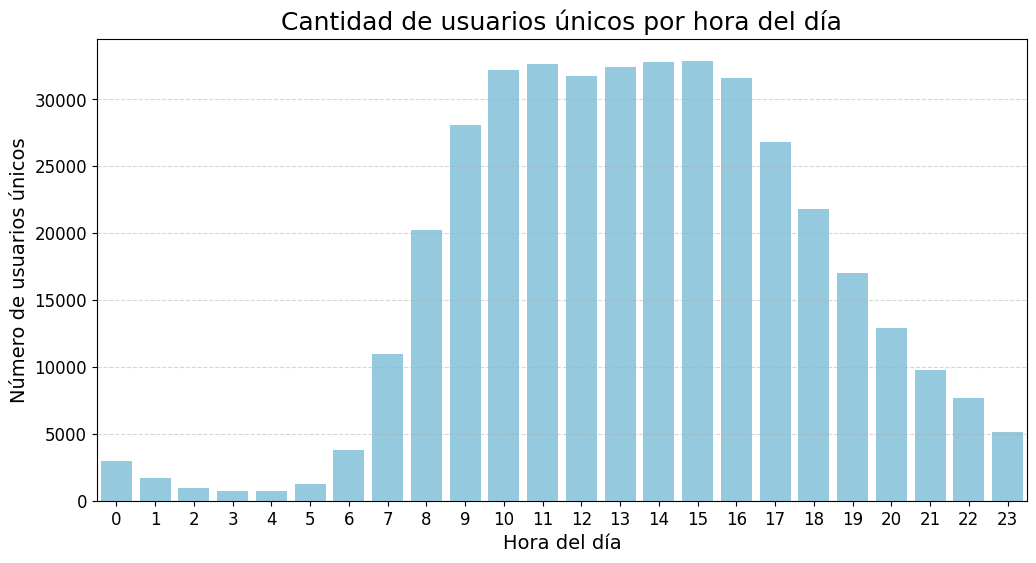

In [89]:
# Agrupación : Contamos usuarios únicos por hora
# Usamos nunique() para contar cuántas personas distintas compraron, no cuántas órdenes hubo.
df_usuarios_por_hora = df_orders.groupby('order_hour_of_day')['user_id'].nunique().reset_index()

# Renombramos para mayor claridad
df_usuarios_por_hora.columns = ['order_hour_of_day', 'unique_users']

# Visualización: Usamos Barplot en lugar de Histplot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_usuarios_por_hora, 
    x='order_hour_of_day', 
    y='unique_users', 
    color='skyblue'
)

plt.title("Cantidad de usuarios únicos por hora del día", fontsize=18)
plt.xlabel("Hora del día", fontsize=14)
plt.ylabel("Número de usuarios únicos", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [90]:
# Agrupar: Contamos el total de pedidos por hora
pedidos_por_hora = df_orders.groupby('order_hour_of_day')['order_id'].count().reset_index()

# Promedio
# Dividimos el total de pedidos de esa hora entre los 7 días de la semana
# (Asumiendo que queremos el promedio de "un día típico")
dias_en_semana = df_orders['order_dow'].nunique()
pedidos_por_hora['average_orders'] = pedidos_por_hora['order_id'] / dias_en_semana

# Verificamos los datos antes de graficar
print(pedidos_por_hora.head())

   order_hour_of_day  order_id  average_orders
0                  0      3180      454.285714
1                  1      1763      251.857143
2                  2       989      141.285714
3                  3       770      110.000000
4                  4       765      109.285714


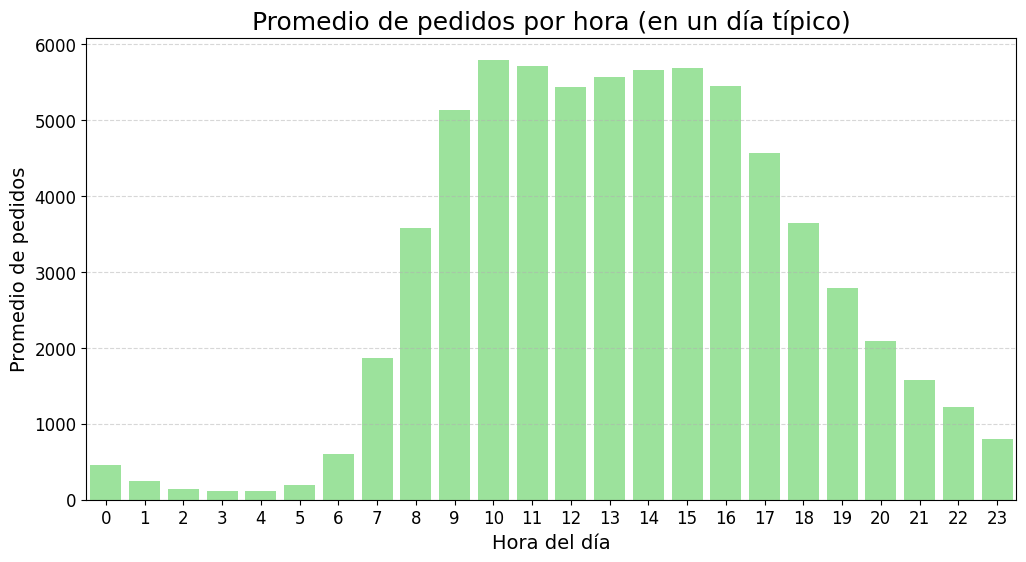

In [92]:
# Visualización: Usamos Barplot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=pedidos_por_hora,
    x='order_hour_of_day',
    y='average_orders',
    color='lightgreen'
)

plt.title("Promedio de pedidos por hora (en un día típico)", fontsize=18)
plt.xlabel("Hora del día", fontsize=14)
plt.ylabel("Promedio de pedidos", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [48]:
tabla_ventas = df_orders.pivot_table(index = 'order_hour_of_day',
                                         columns = 'order_dow',
                                         aggfunc='size',
                                         fill_value=0)

tabla_ventas['Total semanal'] = tabla_ventas.sum(axis=1)


print(tabla_ventas)

order_dow             0     1     2     3     4     5     6  Total semanal
order_hour_of_day                                                         
0                   533   565   462   373   324   459   464           3180
1                   337   269   240   215   229   219   254           1763
2                   188   145   136   106   114   123   177            989
3                   128   104   104   101   109    99   125            770
4                   108   104   109   108   100   118   118            765
5                   171   246   196   170   198   229   161           1371
6                   463   757   653   643   594   654   451           4215
7                  1752  2320  1900  1732  1787  1933  1619          13043
8                  3908  4751  3485  3125  3136  3373  3246          25024
9                  5650  7262  5057  4490  4332  4794  4311          35896
10                 6978  7881  5489  5026  4938  5347  4919          40578
11                 7186  

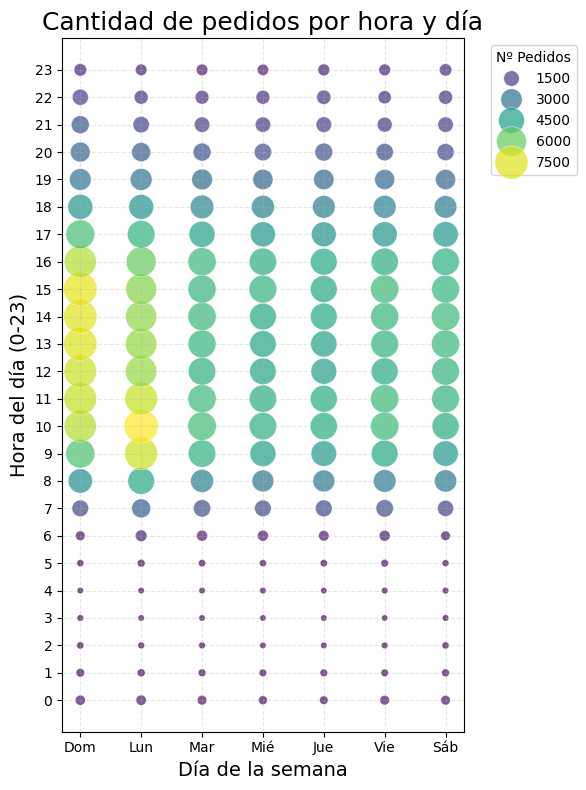

In [93]:
df_para_graficar = df_orders.groupby(['order_dow', 'order_hour_of_day']).size().reset_index(name = 'cantidad_pedidos')


plt.figure(figsize=(6, 8))

# Usamos scatterplot de Seaborn
sns.scatterplot(
    data=df_para_graficar,
    x="order_dow",
    y="order_hour_of_day",
    size="cantidad_pedidos",  
    hue="cantidad_pedidos",   
    palette="viridis",        
    sizes=(20, 600),          
    alpha=0.7
)

# Labels y título
plt.title('Cantidad de pedidos por hora y día', fontsize=18)
plt.xlabel('Día de la semana', fontsize=14)
plt.ylabel('Hora del día (0-23)', fontsize=14)

plt.xticks(range(7), ['Dom', 'Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb'])
plt.yticks(range(24))
plt.grid(True, linestyle='--', alpha=0.3)

# Leyenda afuera
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Nº Pedidos')

plt.tight_layout()
plt.show()

In [50]:
def concentracion_ventas(df, columna, col_name, objetivo_por=0.8):
    """
    Esta función identifica los valores en una columna que concentran un porcentaje.
    parametros:
    df (DataFrame): DataFrame que contiene los datos de pedidos.
    columna (str): Nombre de la columna a analizar.
    col_name (list): Nombres de las columnas del DataFrame resultante.
    objetivo_por (float): Porcentaje objetivo de concentración de ventas (entre 0 y 1)"""
    # 1. Contar pedidos por hora
    conteo = df[columna].value_counts().reset_index()
    conteo.columns = col_name
    
    # 2. Ordenar de mayor a menor
    conteo = conteo.sort_values(by='pedidos', ascending=False)
    
    # 3. Calcular porcentaje individual y acumulado
    total_pedidos = conteo['pedidos'].sum()
    conteo['por_individual'] = conteo['pedidos'] / total_pedidos
    conteo['por_acumulado'] = conteo['por_individual'].cumsum()
    
    # 4. Filtrar
    top = conteo[conteo['por_acumulado'] <= objetivo_por]

    return top

In [51]:
df_resultado = concentracion_ventas(df_orders, "order_hour_of_day", ['hora', 'pedidos'])

print(f"El 80% de las ventas se concentra en {len(df_resultado)} horas:")
print(df_resultado[['hora', 'pedidos', 'por_acumulado']])

El 80% de las ventas se concentra en 10 horas:
   hora  pedidos  por_acumulado
0    10    40578       0.084722
1    11    40032       0.168305
2    15    39789       0.251380
3    14    39631       0.334125
4    13    39007       0.415568
5    16    38112       0.495141
6    12    38034       0.574552
7     9    35896       0.649499
8    17    31930       0.716166
9    18    25510       0.769428


Escribe aquí tus conclusiones.

Las principales horas de venta se encuentran entre las 9 h y las 18 h. Esto quiere decir que los clientes concentrar sus comprar durante el día, particularmente el 80 % de las ventas son entre esas 10 horas del día.

### [A3] ¿Qué día de la semana compran víveres las personas?

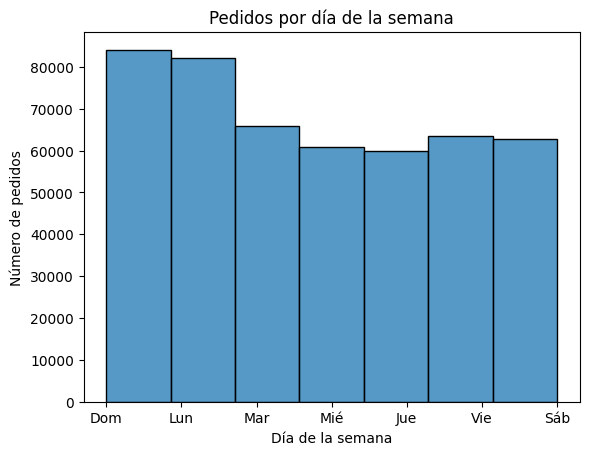

In [94]:
sns.histplot(df_orders['order_dow'], bins = 7, kde=False)

plt.title("Pedidos por día de la semana")
plt.ylabel("Número de pedidos")
plt.xlabel("Día de la semana")

plt.xticks(range(7), ['Dom', 'Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb'])
plt.show()

In [53]:
df_resultado = concentracion_ventas(df_orders, "order_dow", ['día', 'pedidos'], objetivo_por=0.80)

print(f"El 80% de las ventas se concentra en {len(df_resultado)} días:")
print(df_resultado[['día', 'pedidos', 'por_acumulado']])

El 80% de las ventas se concentra en 5 días:
   día  pedidos  por_acumulado
0    0    84090       0.175571
1    1    82185       0.347164
2    2    65833       0.484616
3    5    63488       0.617172
4    6    62649       0.747977


Escribe aquí tus conclusiones.

Los días con mayor demanda son domingo y lunes acumulando un 34.71 % de las ventas de toda la semana. Los día con menos pedidos son el viernes y sábado. Dado esto es mejor asegurarse que haya suficientes productos para el domingo donde sabemos que las horas con mayor ventas son entre 9 h y 18 h.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

In [54]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 478952 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   order_id                478952 non-null  int64
 1   user_id                 478952 non-null  int64
 2   order_number            478952 non-null  int64
 3   order_dow               478952 non-null  int64
 4   order_hour_of_day       478952 non-null  int64
 5   days_since_prior_order  478952 non-null  Int64
dtypes: Int64(1), int64(5)
memory usage: 26.0 MB


In [55]:
df_orders['days_since_prior_order'].describe()

count     478952.0
mean     10.433853
std       9.292153
min            0.0
25%            4.0
50%            7.0
75%           15.0
max           30.0
Name: days_since_prior_order, dtype: Float64

Text(0.5, 1.0, 'Pedidos por días transcurridos desde el pedido anterior')

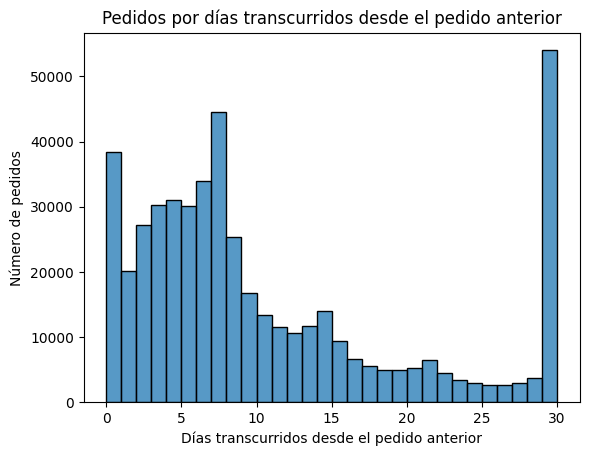

In [56]:
sns.histplot(df_orders['days_since_prior_order'], bins = 30, kde = False)
plt.ylabel('Número de pedidos')
plt.xlabel('Días transcurridos desde el pedido anterior')

plt.title("Pedidos por días transcurridos desde el pedido anterior")

Escribe aquí tus conclusiones.

El tiempo mínimo registrado es de 0 días, esto quiere decir que hay usuarios que hacen dos pedidos en el mismo día. Por otro lado, el tiempo máximo registrado es de 30 días.

El tiempo promedio entre pedidos es de 10.4 días, lo que sugiere que la mayoría de los clientes hacen pedidos aproximadamente cada 10 días. Sin embargo, la distribución de los tiempos entre pedidos es asimétrica, con una mediana de 7 días, lo que indica que la mitad de los clientes hacen pedidos cada semana o menos, mientras que algunos clientes pueden esperar mucho más tiempo entre pedidos. Esto sugiere que hay una variedad de comportamientos de compra entre los clientes, con algunos haciendo pedidos con mucha frecuencia y otros con menos frecuencia. Es importante considerar esta diversidad al planificar estrategias de marketing y gestión de inventario para satisfacer las necesidades de diferentes segmentos de clientes.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

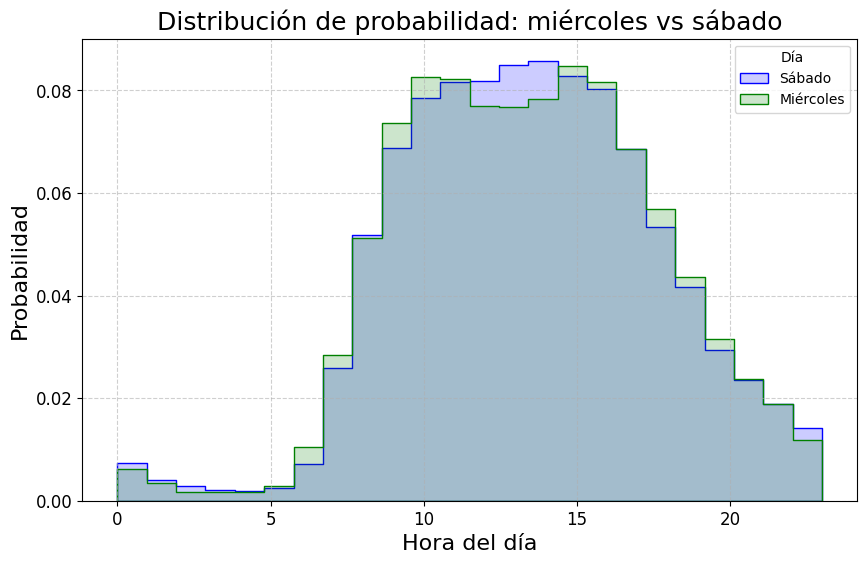

In [96]:
comparativa = df_orders[df_orders['order_dow'].isin([3, 6])]

plt.figure(figsize=(10, 6))
sns.histplot(data=comparativa, 
             x='order_hour_of_day', 
             hue='order_dow',
             bins=24, 
             element='step',
             fill=True,
             alpha=0.2, 
             stat='probability',
             common_norm=False,
             palette={3: 'green', 6: 'blue'})

plt.title("Distribución de probabilidad: miércoles vs sábado", fontsize = 18)
plt.xlabel("Hora del día", fontsize = 16)
plt.ylabel("Probabilidad", fontsize = 16)

plt.yticks(fontsize = 12)
plt.xticks(fontsize = 12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title='Día', labels=['Sábado', 'Miércoles'])
plt.show()

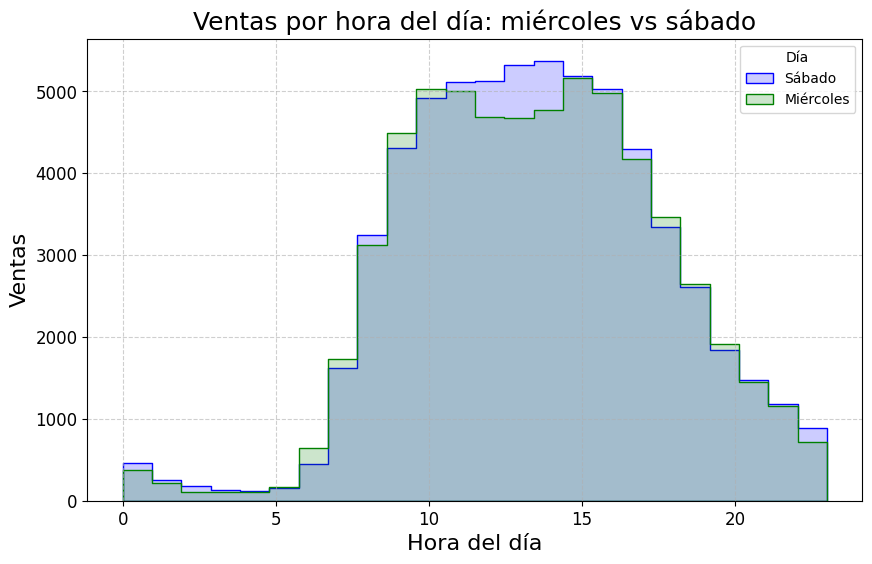

In [98]:
comparativa = df_orders[df_orders['order_dow'].isin([3, 6])]

plt.figure(figsize=(10, 6))
sns.histplot(data=comparativa, 
             x='order_hour_of_day', 
             hue='order_dow',
             bins=24, 
             element='step',
             fill=True,
             alpha=0.2, 
#             stat='probability',
             common_norm=False,
             palette={3: 'green', 6: 'blue'})

plt.title("Ventas por hora del día: miércoles vs sábado", fontsize = 18)
plt.xlabel("Hora del día", fontsize = 16)
plt.ylabel("Ventas", fontsize = 16)

plt.yticks(fontsize = 12)
plt.xticks(fontsize = 12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title='Día', labels=['Sábado', 'Miércoles'])
plt.show()

In [99]:
from scipy.stats import entropy, ks_2samp

def obtener_datos_y_metricas(df, dia_num):
    # Filtramos la serie de datos
    data = df[df['order_dow'] == dia_num]['order_hour_of_day']
    
    # Cálculos para la tabla
    counts = data.value_counts().sort_index()
    probs = counts / counts.sum()
    H = entropy(probs, base=2)
    sigma = data.std()
    
    return data, H, sigma, len(data)

# Obtenemos datos y métricas
raw_mie, h_mie, sigma_mie, n_mie = obtener_datos_y_metricas(df_orders, 3)
raw_sab, h_sab, sigma_sab, n_sab = obtener_datos_y_metricas(df_orders, 6)

# Ejecutamos la prueba Kolmogorov-Smirnov comparando las dos muestras
ks_stat, ks_p_val = ks_2samp(raw_mie, raw_sab)

# Resumen
resumen = pd.DataFrame({
    'Métrica': ['Total Pedidos (N)', 'Entropía (H)', 'Dispersión (σ)', 'KS Statistic (D)', 'KS P-value'],
    'Miércoles': [n_mie, f"{h_mie:.3f} bits", f"{sigma_mie:.2f} h", "-", "-"],
    'Sábado': [n_sab, f"{h_sab:.3f} bits", f"{sigma_sab:.2f} h", f"{ks_stat:.4f}", f"{ks_p_val:.4e}"]
})

print(resumen)

             Métrica   Miércoles      Sábado
0  Total Pedidos (N)       60897       62649
1       Entropía (H)  4.072 bits  4.069 bits
2     Dispersión (σ)      4.26 h      4.26 h
3   KS Statistic (D)           -      0.0118
4         KS P-value           -  3.6899e-04


Escribe aquí tus conclusiones.

Podemos ver algo interesante en estos gráficos y en la tabla final. El día sábado tiene una cantidad de ventas superior al miércoles, como lo podemos ver en el histograma de ventas.

Respecto a qué tan significativa es esta diferentecia se puede concluir que es casi nula la diferencia. Podríamos tratar a ambos días como semejantes con pequeñas variaciones al comparar las proporciones de ambos basándonos en la prueba de Kolmogorov-Smirnov.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [60]:
# Distribución de pedidos por cliente 
pedidos_por_cliente = df_orders.groupby('user_id')['order_id'].nunique().reset_index(name='num_pedidos')
print(pedidos_por_cliente.head())
print("Resumen estadístico de pedidos por cliente:")
print(pedidos_por_cliente['num_pedidos'].describe())
print("-" * 30)

   user_id  num_pedidos
0        2            2
1        4            2
2        5            1
3        6            2
4        7            2
Resumen estadístico de pedidos por cliente:
count    157437.000000
mean          3.042182
std           2.746842
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          28.000000
Name: num_pedidos, dtype: float64
------------------------------


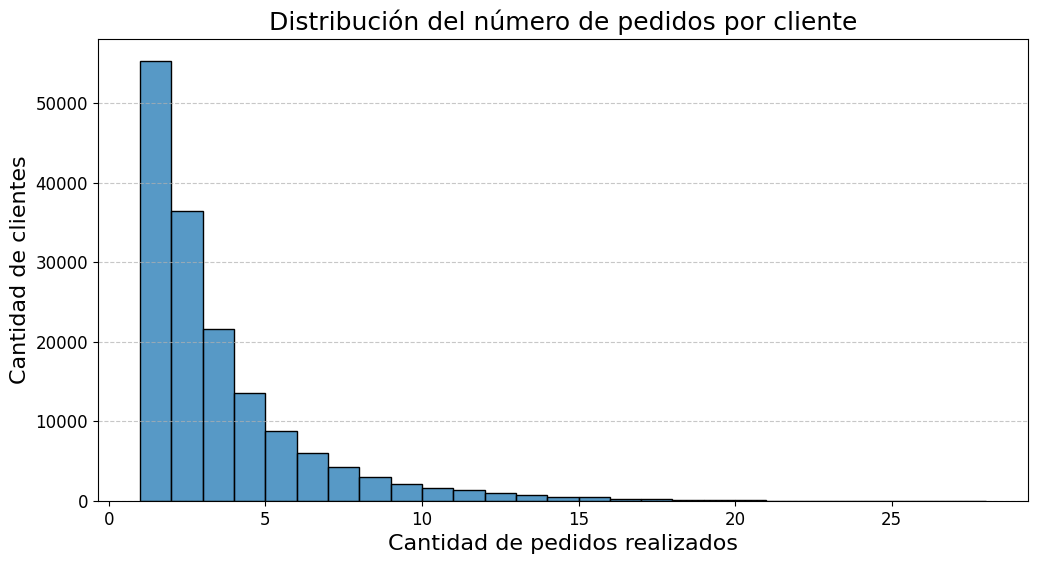

In [61]:
# 3. Gráfica de distribución
plt.figure(figsize=(12, 6))

sns.histplot(pedidos_por_cliente['num_pedidos'], 
             bins=range(pedidos_por_cliente['num_pedidos'].min(), pedidos_por_cliente['num_pedidos'].max() + 1), 
             kde=False,
             edgecolor='black')

plt.title("Distribución del número de pedidos por cliente", fontsize=18)
plt.xlabel("Cantidad de pedidos realizados", fontsize=16)
plt.ylabel("Cantidad de clientes", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Escribe aquí tus conclusiones.

Podemos ver que el 50 % de los clientes hicieron entre uno y dos pedidos. El número máximo de pedidos por cliente es de 28, pero esto es un caso atípico ya que el 75 % de los clientes hicieron 4 pedidos o menos. Es importante considerar esta distribución al diseñar estrategias de marketing y retención para diferentes segmentos de clientes.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [62]:
# Contar ventas y calcular porcentajes por producto
ventas_productos = df_order_products['product_id'].value_counts().reset_index()
ventas_productos.columns = ['product_id', 'total_sales']

total_articulos = len(df_order_products)
ventas_productos['percentage'] = (ventas_productos['total_sales'] / total_articulos) * 100

# Unir con df_products para obtener nombres
df_completo = ventas_productos.merge(df_products, on='product_id')

# Unir con df_aisles para obtener el nombre del pasillo
df_completo = df_completo.merge(df_aisles, on='aisle_id')

# Unir con df_departments para obtener el nombre del departamento
df_completo = df_completo.merge(df_departments, on='department_id')


columnas_finales = [
    'product_id', 
    'product_name', 
    'total_sales', 
    'percentage', 
    'aisle', 
    'department'
]

# Aplicamos el filtro de columnas y ordenamos por ventas
productos_populares_reporte = df_completo[columnas_finales].sort_values(by='total_sales', ascending=False)


print("Top 20 productos más vendidos con detalles de ubicación:")
print(productos_populares_reporte.head(20))

Top 20 productos más vendidos con detalles de ubicación:
    product_id              product_name  total_sales  percentage  \
0        24852                    Banana        66050    1.453243   
1        13176    Bag of Organic Bananas        53297    1.172649   
2        21137      Organic Strawberries        37039    0.814938   
3        21903      Organic Baby Spinach        33971    0.747436   
4        47209      Organic Hass Avocado        29773    0.655070   
5        47766           Organic Avocado        24689    0.543211   
6        47626               Large Lemon        21495    0.472937   
7        16797              Strawberries        20018    0.440439   
8        26209                     Limes        19690    0.433223   
9        27845        Organic Whole Milk        19600    0.431242   
10       27966       Organic Raspberries        19197    0.422376   
11       22935      Organic Yellow Onion        15898    0.349790   
12       24964            Organic Garlic      

Escribe aquí tus conclusiones.

Los productos 5 productos más populares son el plátano, la fresa, espinacas baby, aguacate hass, limón y limas. La lista general de productos son de consumo común y se pueden considerar como productos básicos en la mayoría de los hogares. Es importante asegurarse de que estos productos estén siempre disponibles en el inventario para satisfacer la demanda de los clientes. Además, se podrían diseñar promociones o descuentos para estos productos populares para atraer a más clientes y aumentar las ventas.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [63]:
artículos_por_pedido = df_order_products.groupby('order_id')['product_id'].count().reset_index(name='num_productos')
print(artículos_por_pedido.head())

# Descripción estadística de número de productos por pedido
print(artículos_por_pedido['num_productos'].describe())

   order_id  num_productos
0         4             13
1         9             15
2        11              5
3        19              3
4        20              8
count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: num_productos, dtype: float64


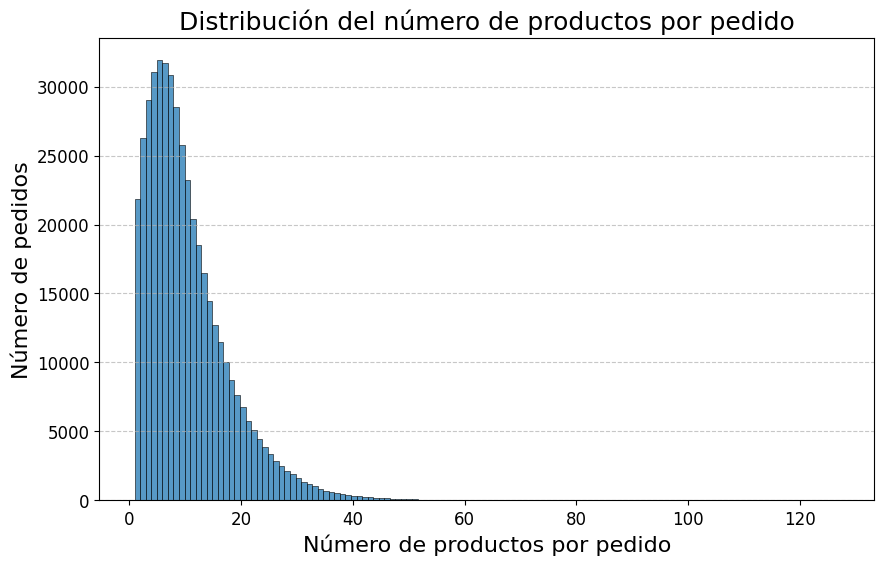

In [64]:
# Gráfica de distribución de número de artículos por pedido
plt.figure(figsize=(10, 6))
sns.histplot(artículos_por_pedido['num_productos'], bins=127, kde=False)

plt.title("Distribución del número de productos por pedido", fontsize=18)
plt.xlabel("Número de productos por pedido", fontsize=16)
plt.ylabel("Número de pedidos", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

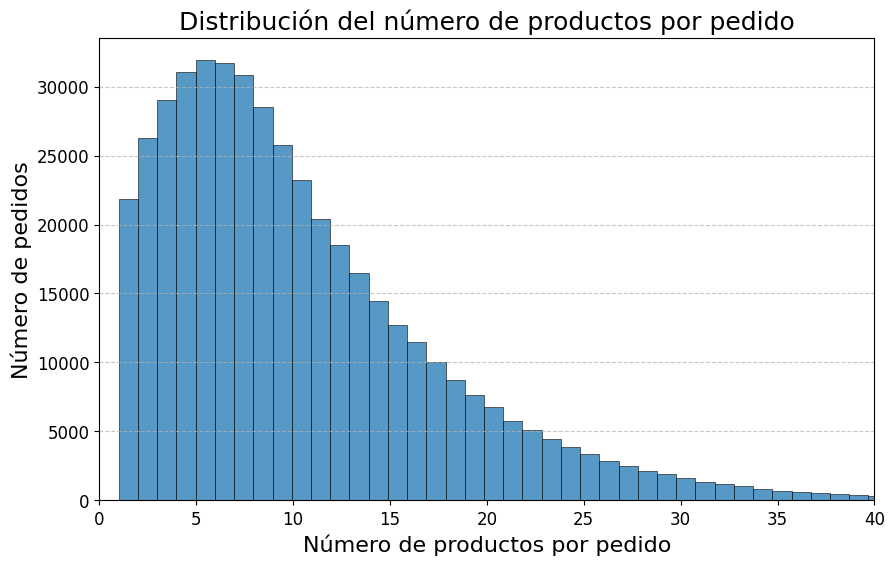

In [65]:
# Gráfica de distribución de número de artículos por pedido
plt.figure(figsize=(10, 6))
sns.histplot(artículos_por_pedido['num_productos'], bins=127, kde=False)

plt.title("Distribución del número de productos por pedido", fontsize=18)
plt.xlabel("Número de productos por pedido", fontsize=16)
plt.ylabel("Número de pedidos", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xlim(0, 40)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Escribe aquí tus conclusiones.

Podemos ver que la cantidad de productos por pedido varía entre 1 y 127, con un promedio de 10 productos por pedido. Sin embargo, la distribución de la cantidad de productos por pedido es asimétrica, con una mediana de 8 productos por pedido, mientras que el 75 % de los usuarios compra 14 o menos productos por pedido. Es importante considerar esta distribución al planificar estrategias de marketing y gestión de inventario para satisfacer las necesidades de diferentes segmentos de clientes.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [ ]:
articulos_mas_pedidos = df_order_products.groupby('product_id')['reordered'].sum().reset_index(name='veces_repedido')
articulos_mas_pedidos = articulos_mas_pedidos.sort_values(by='veces_repedido', ascending=False)
articulos_mas_pedidos = articulos_mas_pedidos.merge(df_products[['product_id', 'product_name']], on='product_id')
print("Top 20 artículos más repedidos:")
print(articulos_mas_pedidos.head(20))

Top 20 artículos más repedidos:
    product_id  veces_repedido              product_name
0        24852           55763                    Banana
1        13176           44450    Bag of Organic Bananas
2        21137           28639      Organic Strawberries
3        21903           26233      Organic Baby Spinach
4        47209           23629      Organic Hass Avocado
5        47766           18743           Organic Avocado
6        27845           16251        Organic Whole Milk
7        47626           15044               Large Lemon
8        27966           14748       Organic Raspberries
9        16797           13945              Strawberries
10       26209           13327                     Limes
11       22935           11145      Organic Yellow Onion
12       24964           10411            Organic Garlic
13       45007           10076          Organic Zucchini
14       49683            9538            Cucumber Kirby
15       28204            8989        Organic Fuji Apple

Escribe aquí tus conclusiones.

Los artículos más repetidos son el plátanos, las fresas, las espinacas, el aguacate y la leche. Lo cual concuerda con los productos más populares enlistados anteriormente. Es importante asegurarse de que estos productos estén siempre disponibles en el inventario para satisfacer la demanda de los clientes. Además, se podrían diseñar promociones o descuentos para estos productos populares para atraer a más clientes y aumentar las ventas.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [101]:
# Agrupamos por producto y calculamos la media (proporción)
# Nota: No filtramos por ventas mínimas todavía. Queremos el dato para todos.
df_proporciones = df_order_products.groupby('product_id')['reordered'].mean().reset_index()

# Renombramos la columna para que sea explícita
df_proporciones.columns = ['product_id', 'reorder_ratio']

# Unimos con df_products para obtener el nombre
# Esto asigna el nombre a CADA ID calculado anteriormente
tabla_completa_productos = df_proporciones.merge(df_products[['product_id', 'product_name']], on='product_id')


# --- Tabla Completa ---

print("Tabla completa de proporción de reorden por producto (Primeras filas):")
# Aquí mostramos el dataframe que contiene TODOS los productos vendidos
print(tabla_completa_productos.head()) 
print(f"Total de productos analizados: {len(tabla_completa_productos)}")
print("="*70)


# --- Análisis ---

# Creamos una vista ordenada descendente para ver los más reordenados
top_reordenados = tabla_completa_productos.sort_values(by='reorder_ratio', ascending=False)

print("\nVista de los productos con mayor tasa de reorden (Top 10):")
print(top_reordenados.head(10))

Tabla completa de proporción de reorden por producto (Primeras filas):
   product_id  reorder_ratio  \
0           1       0.564286   
1           2       0.000000   
2           3       0.738095   
3           4       0.510204   
4           7       0.500000   

                                        product_name  
0                         Chocolate Sandwich Cookies  
1                                   All-Seasons Salt  
2               Robust Golden Unsweetened Oolong Tea  
3  Smart Ones Classic Favorites Mini Rigatoni Wit...  
4                     Pure Coconut Water With Orange  
Total de productos analizados: 45573

Vista de los productos con mayor tasa de reorden (Top 10):
       product_id  reorder_ratio  \
13453       14721            1.0   
19195       20949            1.0   
6136         6723            1.0   
6144         6732            1.0   
41319       45088            1.0   
41310       45078            1.0   
19258       21016            1.0   
19248       21005    

In [103]:
# Agrupamos y pedimos DOS métricas:
# 'mean': para la proporción (lo que pide el ejercicio)
# 'count': para saber el volumen de ventas (lo necesitamos para filtrar)
df_resumen = df_order_products.groupby('product_id')['reordered'].agg(['mean', 'count']).reset_index()

# Renombramos para que sea claro
df_resumen.columns = ['product_id', 'proporcion_repedidos', 'total_ventas']

# Unimos con los nombres de los productos
df_completo = df_resumen.merge(df_products[['product_id', 'product_name']], on='product_id')

print("Tabla completa generada.")
print(f"Total de productos únicos: {len(df_completo)}")
print("-" * 60)

# --- Aplicamos el filtro ---

# Aquí creamos un subconjunto. No borramos el anterior, solo creamos una vista nueva.
# Filtro: Solo con las filas donde 'total_ventas' sea mayor a 100
df_filtrado = df_completo[df_completo['total_ventas'] > 100]

# Ordenamos este dataframe filtrado por la proporción para ver los más leales
df_filtrado = df_filtrado.sort_values(by='proporcion_repedidos', ascending=False)

# --- Resultados ---

print("Análisis de productos con más de 100 ventas:")
print(f"Productos restantes después del filtro: {len(df_filtrado)}")
print("\nTop 10 productos con mayor tasa de recompra (High Volume & High Loyalty):")
print(df_filtrado.head(10))

Tabla completa generada.
Total de productos únicos: 45573
------------------------------------------------------------
Análisis de productos con más de 100 ventas:
Productos restantes después del filtro: 6479

Top 10 productos con mayor tasa de recompra (High Volume & High Loyalty):
       product_id  proporcion_repedidos  total_ventas  \
8483         9292              0.876574           397   
2450         2677              0.871345           171   
43292       47231              0.868293           205   
1046         1157              0.863946           147   
41704       45504              0.863142          1286   
27013       29447              0.862847          2880   
31363       34197              0.859135           717   
5045         5514              0.857664           548   
29094       31720              0.855137          1353   
22498       24521              0.853801           171   

                            product_name  
8483     Half And Half Ultra Pasteurized  
24

Escribe aquí tus conclusiones.

Podemos ver que los productos con mayor tasa de repetición en compras no necesariamente son los productos más populares encontrados anteriormente. Inclusive, cuando hacemos un filtro a más de 100 compras, si bien cambia la lista, no son los más populares en términos generales. Esto no quiere decir que los productos con mayor tasa de repetición no sean populares, sino que no son los más populares. Esto se puede deber a que hay productos que aunque no son tan populares, las personas que los compran tienden a comprarlos de forma recurrente. Por ejemplo, el producto con mayor tasa de repetición es el agua ultra purificada, el cual no es tan popular como el plátano pero las personas que lo compran tienden a comprarlo de forma recurrente. Esto nos podría hablar de la fidelidad de ciertos productos, es decir, aunque no sean los más populares, las personas que los compran tienden a comprarlos de forma recurrente.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [105]:
# Se tomará el df_order para clasificar por 'user_id' junto con 'order_id'
# para tomar el número de orden y hacer un merge con df_order_products
# y así obtener cuántos productos se han pedido antes basándose en 'reordered' de df_order_products
# Así podemos contar el total de pedidos comprados y cuál es la proporción de productos 
# ya pedidos anteriormente por cada cliente.
proporciones = df_orders[['user_id', 'order_id']].merge(df_order_products[['order_id', 'reordered']], on='order_id', how='left')
proporciones_cliente = proporciones.groupby('user_id')['reordered'].agg(['sum', 'count']).reset_index()
proporciones_cliente.columns = ['user_id', 'total_repedidos', 'total_productos']
proporciones_cliente['proporcion_repedidos'] = (
    proporciones_cliente['total_repedidos'] / proporciones_cliente['total_productos']).fillna(0)


# --- Verificación ---

print("--- Verificación de dimensiones ---")
# Mostramos las dimensiones: (filas, columnas)
print(f"Dimensiones de la tabla resultante (filas, columnas): {proporciones_cliente.shape}")

# Confirmamos cuántos usuarios únicos se procesaron
total_usuarios_calculados = proporciones_cliente['user_id'].nunique()
print(f"Total de usuarios únicos con proporción calculada: {total_usuarios_calculados}")

# Comparación con el total original para demostrar que están todos lo elementos
total_usuarios_originales = df_orders['user_id'].nunique()
print(f"Total de usuarios en el dataset original (df_orders): {total_usuarios_originales}")

if total_usuarios_calculados == total_usuarios_originales:
    print("Se han calculado las proporciones para la totalidad de los usuarios.")
else:
    print("Hay una discrepancia en el número de usuarios.")

print("\n--- Muestra de los datos (Primeras filas) ---")
print(proporciones_cliente.head())

--- Verificación de dimensiones ---
Dimensiones de la tabla resultante (filas, columnas): (157437, 4)
Total de usuarios únicos con proporción calculada: 157437
Total de usuarios en el dataset original (df_orders): 157437
Se han calculado las proporciones para la totalidad de los usuarios.

--- Muestra de los datos (Primeras filas) ---
   user_id  total_repedidos  total_productos  proporcion_repedidos
0        2              1.0               26              0.038462
1        4              0.0                2              0.000000
2        5              8.0               12              0.666667
3        6              0.0                4              0.000000
4        7             13.0               14              0.928571


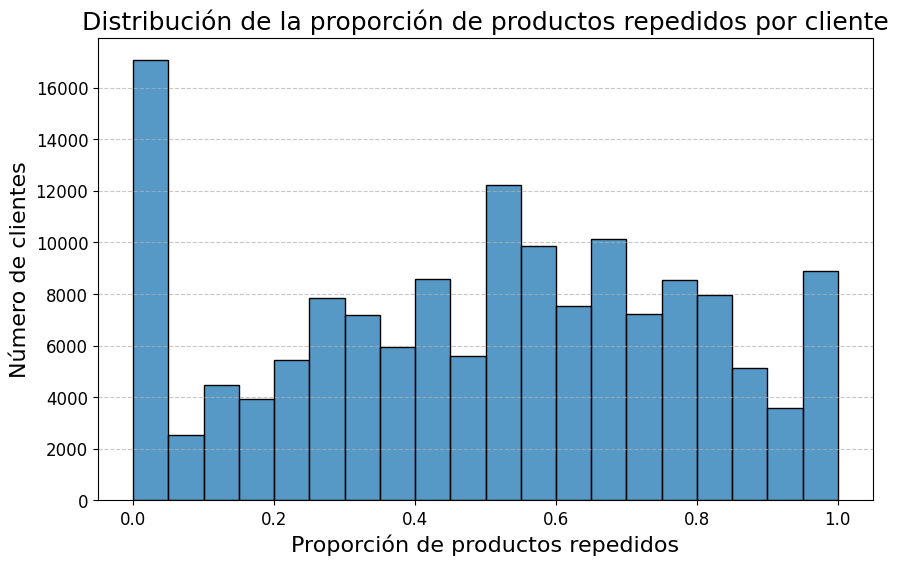

In [84]:
# histograma de proporción de repedidos por cliente
plt.figure(figsize=(10, 6))
sns.histplot(proporciones_cliente['proporcion_repedidos'], bins=20, kde=False)
plt.title("Distribución de la proporción de productos repedidos por cliente", fontsize=18)
plt.xlabel("Proporción de productos repedidos", fontsize=16)
plt.ylabel("Número de clientes", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [81]:
proporciones_cliente.describe()

,user_id,total_repedidos,total_productos,proporcion_repedidos
count,149626.000000,149626.000000,149626.000000,149626.000000
mean,103205.167778,17.936976,30.375784,0.494853
std,59560.993992,27.793625,35.873511,0.292685
min,2.000000,0.000000,1.000000,0.000000
25%,51650.250000,2.000000,9.000000,0.272727
50%,103177.000000,8.000000,18.000000,0.500000
75%,154837.750000,21.000000,38.000000,0.724138
max,206209.000000,477.000000,580.000000,1.000000


Escribe aquí tus conclusiones.

Podemos ver que el 50 % de los clientes tienen una tasa de repetición de pedido del 0.5 o menos, lo que sugiere que la mayoría de los clientes no repiten la compra de la mitad o más de los productos que han pedido anteriormente. Sin embargo, hay clientes con tasas de repetición de pedido cercanas a 1, lo que indica que algunos clientes tienden a repetir la compra de la mayoría o todos los productos que han pedido anteriormente. Es importante considerar esta diversidad en el comportamiento de compra al diseñar estrategias de marketing y retención para diferentes segmentos de clientes.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [85]:
# Podemos crear un dataframe con todos los valores '1' dentro de la columna de 'add_to_cart_order'
# del dataframe df_order_products, y así obtener la lista de los productos que son pedidos al inicio
# después creamos un conteo de cuántas veces se repite el productos y así obtenemos los 20 
# principales artículos que las personas ponen primero en su carrito.

primeros_productos = df_order_products[df_order_products['add_to_cart_order'] == 1]
conteo_primeros_productos = primeros_productos['product_id'].value_counts().reset_index()
conteo_primeros_productos.columns = ['product_id', 'veces_primer_producto']
conteo_primeros_productos = conteo_primeros_productos.merge(df_products[['product_id', 'product_name']], on='product_id')
conteo_primeros_productos = conteo_primeros_productos.sort_values(by='veces_primer_producto', ascending=False)
print("Top 20 productos más frecuentemente añadidos primero al carrito:")
print(conteo_primeros_productos.head(20))

Top 20 productos más frecuentemente añadidos primero al carrito:
    product_id  veces_primer_producto                 product_name
0        24852                  15562                       Banana
1        13176                  11026       Bag of Organic Bananas
2        27845                   4363           Organic Whole Milk
3        21137                   3946         Organic Strawberries
4        47209                   3390         Organic Hass Avocado
5        21903                   3336         Organic Baby Spinach
6        47766                   3044              Organic Avocado
7        19660                   2336                 Spring Water
8        16797                   2308                 Strawberries
9        27966                   2024          Organic Raspberries
10       44632                   1914   Sparkling Water Grapefruit
11       49235                   1797          Organic Half & Half
12       47626                   1737                  Large Lem

Escribe aquí tus conclusiones.

Como podemos ver, las bananas son el productos que más veces se añade primero al carrito, esta consistencia muestra cómo este prodria ser el producto estrella de la tienda. Además podemos ver que los productos más populares también son los que más veces se añaden primero al carrito, lo cual es consistente con lo que se esperaría. Es importante asegurarse de que estos productos estén siempre disponibles en el inventario para satisfacer la demanda de los clientes. Además, se podrían diseñar promociones o descuentos para estos productos populares para atraer a más clientes y aumentar las ventas.

### Conclusion general del proyecto:

1. <b>Calidad e integridad de los datos</b> 
   El análisis reveló que la limpieza de datos no puede ser automatizada completamente, sino que requiere contexto de negocio:
   <ol>
   <li><b>Manejo de valores nulos</b>: Los valores ausentes no siempre son errores. En product_name en products, los valores nulos estaban asociados a un pasillo y departamento específicos, ambos con el nombre "missing". Esto sugiere que los valores nulos podrían representar productos sin información registrada, lo que llevó a rellenarlos con "Unknown" en lugar de eliminarlos.
   <li><b>Valores duplicados</b>: Se detectó la necesidad de normalizar textos, como convertir a minúsculas los nombres de productos, para identificar correctamente los vallores duplicados, ya que el método estándar <code>.duplicated()</code> no los detectaba debido a diferencias en mayúsculas y minúsculas.
   </ol>

2. <b>Comportamiento del usuario y productos</b>
    El análisis de los datos reveló patrones interesantes en el comportamiento de compra de los clientes y la popularidad de los productos:
    <ol>
    <li><b>Patrones de compra por hora y día</b>: La mayoría de las compras se realizan entre las 9 h y las 18 h, con un pico los domingos y lunes. Esto sugiere que los clientes prefieren hacer sus compras durante el día, especialmente al inicio de la semana.
    <li><b>Frecuencia de pedidos</b>: El 50 % de los clientes hicieron entre uno y dos pedidos, con un máximo de 28 pedidos por cliente. Esto indica una diversidad en la frecuencia de compra, con algunos clientes haciendo pedidos con mucha frecuencia y otros con menos frecuencia.
    <li><b>Productos populares y repetidos</b>: Los productos más populares incluyen plátanos, fresas, espinacas, aguacate y leche. Sin embargo, los productos con mayor tasa de repetición no necesariamente son los más populares, lo que sugiere que algunos productos tienen una base de clientes leales que los compran de forma recurrente.
    </ol>

3. <b>Implicaciones para el negocio</b>
    Los hallazgos del análisis tienen varias implicaciones para la gestión de inventario, marketing y estrategias de retención de clientes:
    <ol>
    <li><b>Gestión de inventario</b>: Es crucial asegurarse de que los productos más populares y aquellos con alta tasa de repetición estén siempre disponibles en el inventario para satisfacer la demanda de los clientes.
    <li><b>Estrategias de marketing</b>: Se podrían diseñar promociones o descuentos para los productos populares y aquellos con alta tasa de repetición para atraer a más clientes y aumentar las ventas.
    <li><b>Segmentación de clientes</b>: La diversidad en la frecuencia de compra y la tasa de repetición sugiere que es importante segmentar a los clientes en diferentes grupos para diseñar estrategias de marketing y retención más efectivas.
    <li><b>Funcionalidad de «favoritos»</b>: Dado que algunos productos tienen una alta tasa de repetición, podría ser beneficioso implementar una funcionalidad de "favoritos" en la plataforma para facilitar a los clientes la compra de sus productos preferidos.
    </ol>